In [7]:
import pandas as pd
df = pd.read_csv("../data/historical_features.csv")
df.head()

,time,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m,pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide,us_aqi,city
0,2024-01-01T00:00,8.7,72,3.9,0.0,956.1,2.4,333,17.3,26.5,32.5,5.0,3.4,1578.0,151,Islamabad
1,2024-01-01T01:00,5.6,90,4.1,0.0,955.7,3.6,323,19.2,31.5,36.0,6.0,4.4,1463.0,150,Islamabad
2,2024-01-01T02:00,5.9,87,3.9,0.0,956.4,5.1,321,21.7,35.0,40.6,7.0,5.9,1299.0,150,Islamabad
3,2024-01-01T03:00,7.7,83,5.0,0.0,957.3,5.1,315,25.2,39.2,42.5,14.0,7.4,1145.0,150,Islamabad
4,2024-01-01T04:00,11.3,72,6.4,0.0,958.3,4.9,287,28.6,44.5,39.4,29.0,8.6,1015.0,149,Islamabad


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22632 entries, 0 to 22631
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  22632 non-null  str    
 1   temperature_2m        22632 non-null  float64
 2   relative_humidity_2m  22632 non-null  int64  
 3   dew_point_2m          22632 non-null  float64
 4   precipitation         22632 non-null  float64
 5   surface_pressure      22632 non-null  float64
 6   wind_speed_10m        22632 non-null  float64
 7   wind_direction_10m    22632 non-null  int64  
 8   pm2_5                 22632 non-null  float64
 9   pm10                  22632 non-null  float64
 10  nitrogen_dioxide      22632 non-null  float64
 11  ozone                 22632 non-null  float64
 12  sulphur_dioxide       22632 non-null  float64
 13  carbon_monoxide       22632 non-null  float64
 14  us_aqi                22632 non-null  int64  
 15  city                  22632 no

In [12]:
df.isnull().sum()

time                    0
temperature_2m          0
relative_humidity_2m    0
dew_point_2m            0
precipitation           0
surface_pressure        0
wind_speed_10m          0
wind_direction_10m      0
pm2_5                   0
pm10                    0
nitrogen_dioxide        0
ozone                   0
sulphur_dioxide         0
carbon_monoxide         0
us_aqi                  0
city                    0
dtype: int64

In [13]:
df.describe()

,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m,pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide,us_aqi
count,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000
mean,21.902439,58.073303,11.997901,0.126639,949.916972,6.849399,208.204799,37.455501,52.737138,38.880832,78.655753,11.446801,936.517542,111.249691
std,8.234694,21.065170,7.868151,0.718175,5.707281,3.881692,119.175773,21.866389,32.109728,32.083912,59.238132,7.545130,695.897780,32.491605
min,2.500000,7.000000,-19.100000,0.000000,934.400000,0.000000,1.000000,3.100000,3.200000,0.000000,0.000000,0.000000,14.000000,51.000000
25%,15.200000,42.000000,5.900000,0.000000,945.300000,4.000000,87.000000,21.800000,30.900000,12.800000,27.000000,6.200000,432.000000,85.000000
50%,22.800000,60.000000,11.300000,0.000000,950.300000,6.200000,261.000000,32.000000,44.800000,29.300000,68.000000,9.500000,695.000000,104.000000
75%,28.100000,74.000000,18.800000,0.000000,954.600000,8.900000,317.000000,47.600000,66.100000,57.500000,124.000000,14.400000,1231.000000,139.000000
max,44.300000,100.000000,27.500000,15.900000,966.600000,35.200000,360.000000,170.900000,501.100000,175.000000,248.000000,54.200000,5420.000000,218.000000


In [14]:
df["time"] = pd.to_datetime(df["time"])
print(df["time"].min(), df["time"].max())
print(len(df))

2024-01-01 00:00:00 2026-07-31 23:00:00
22632


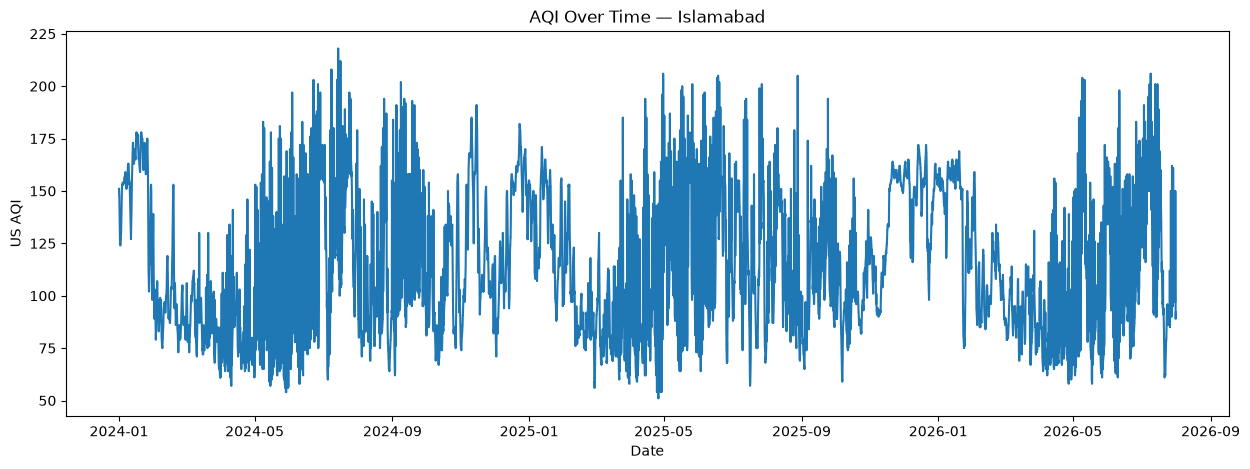

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(df["time"], df["us_aqi"])
plt.title("AQI Over Time — Islamabad")
plt.xlabel("Date")
plt.ylabel("US AQI")
plt.show()

<Axes: title={'center': 'Monthly Average: PM2.5 vs Ozone vs AQI'}, xlabel='time'>

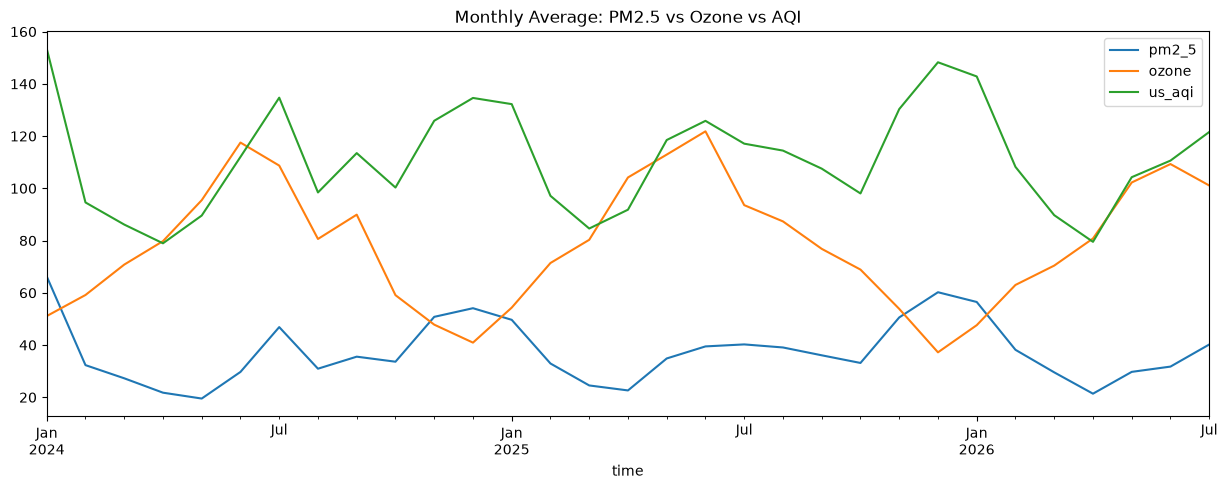

In [18]:
df.set_index("time")[["pm2_5", "ozone", "us_aqi"]].resample("ME").mean().plot(figsize=(15,5), title="Monthly Average: PM2.5 vs Ozone vs AQI")

In [20]:
df[["temperature_2m", "relative_humidity_2m", "dew_point_2m", "precipitation", 
    "surface_pressure", "wind_speed_10m", "wind_direction_10m",
    "pm2_5", "pm10", "nitrogen_dioxide", "ozone", "sulphur_dioxide", "carbon_monoxide", 
    "us_aqi"]].corr()["us_aqi"].sort_values(ascending=False)

us_aqi                  1.000000
pm2_5                   0.570496
pm10                    0.488047
sulphur_dioxide         0.408609
carbon_monoxide         0.304685
nitrogen_dioxide        0.174204
relative_humidity_2m    0.087299
surface_pressure        0.059851
ozone                   0.053616
dew_point_2m            0.008500
wind_direction_10m     -0.030869
precipitation          -0.050895
temperature_2m         -0.063873
wind_speed_10m         -0.133962
Name: us_aqi, dtype: float64

In [21]:
df["us_aqi"].corr(df[["pm2_5", "pm10", "nitrogen_dioxide", "ozone", "sulphur_dioxide", "carbon_monoxide"]].max(axis=1))

np.float64(0.3046836428288068)

In [22]:
df[["temperature_2m", "relative_humidity_2m", "dew_point_2m", "precipitation", 
    "surface_pressure", "wind_speed_10m", "wind_direction_10m"]].corrwith(df["pm2_5"]).sort_values(ascending=False)

relative_humidity_2m    0.316441
surface_pressure        0.179990
dew_point_2m           -0.009627
precipitation          -0.048546
wind_direction_10m     -0.068651
wind_speed_10m         -0.193750
temperature_2m         -0.302495
dtype: float64

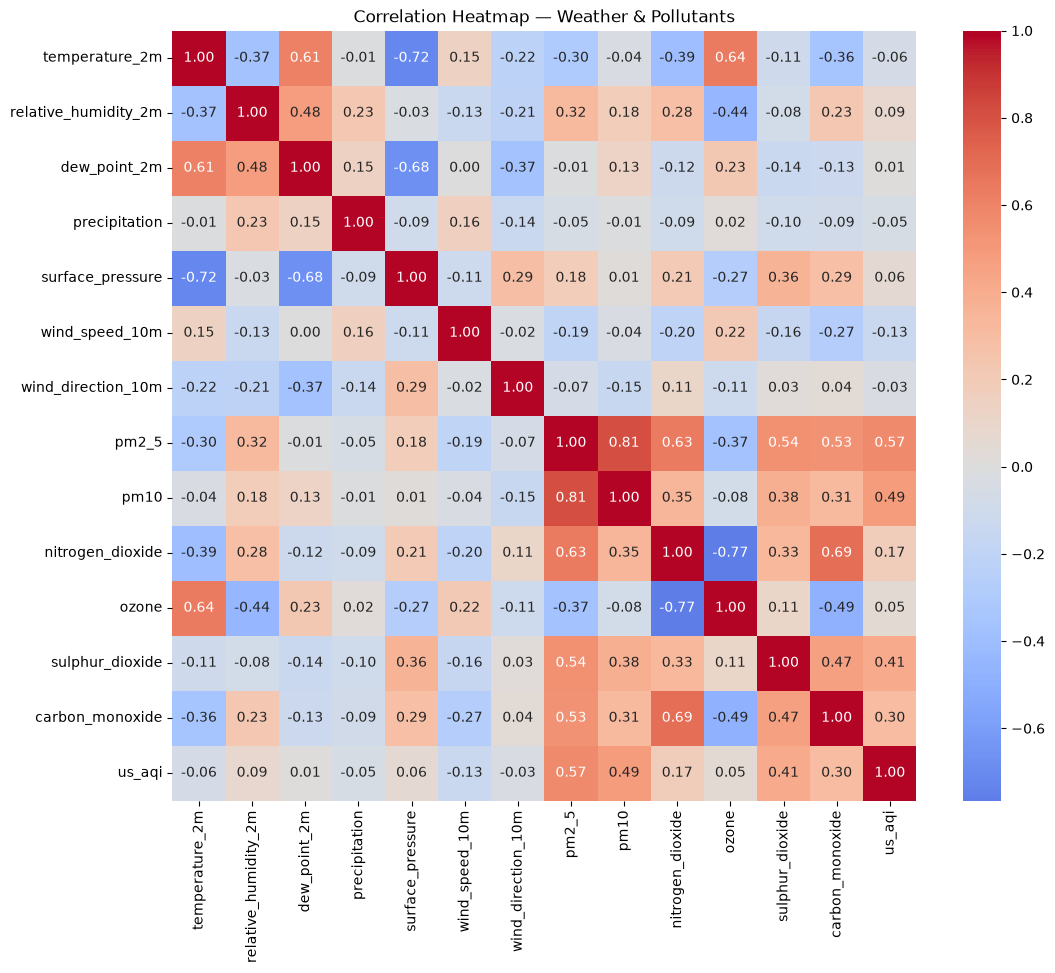

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["temperature_2m", "relative_humidity_2m", "dew_point_2m", "precipitation",
        "surface_pressure", "wind_speed_10m", "wind_direction_10m",
        "pm2_5", "pm10", "nitrogen_dioxide", "ozone", "sulphur_dioxide", "carbon_monoxide", "us_aqi"]

plt.figure(figsize=(12, 10))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Weather & Pollutants")
plt.show()

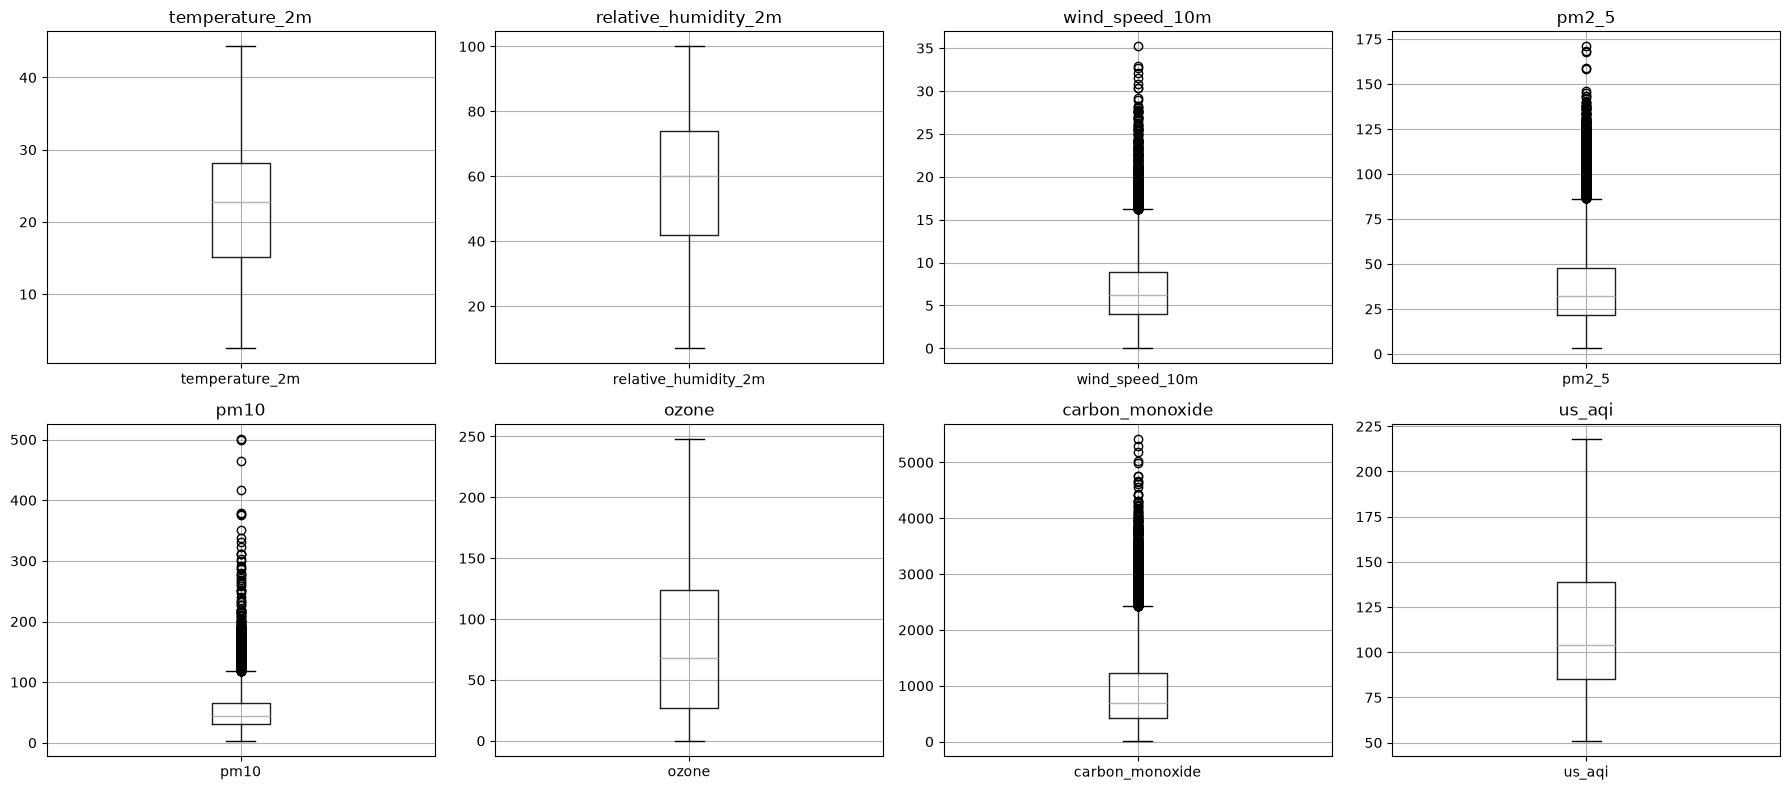

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
outlier_cols = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "pm2_5", "pm10", "ozone", "carbon_monoxide", "us_aqi"]

for ax, col in zip(axes.flat, outlier_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [2]:
import shap

# SHAP for the 24h XGBoost model
explainer_24h = shap.TreeExplainer(model_24h)
shap_values_24h = explainer_24h.shap_values(X_test)

# Summary plot — shows overall feature importance + how each feature's value affects predictions
shap.summary_plot(shap_values_24h, X_test, show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "notebooks", "shap_summary_24h.png"), dpi=150)
plt.close()
print("Saved SHAP summary plot for 24h model")

NameError: name 'model_24h' is not defined